In [6]:
# step1 : install and import libraries

!pip install kaggle -q
!pip install seaborn -q
!pip install scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
# Sklearn — allowed ONLY for evaluation & baseline models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
print(' All libraries imported successfully!')


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: C:\Users\91759\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: C:\Users\91759\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


 All libraries imported successfully!



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: C:\Users\91759\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
#step2: load dataset

df= pd.read_csv("UCI_Credit_Card.csv")

In [8]:
# task 1 : data preprocessing
df.shape

(30000, 25)

In [9]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [10]:
df.tail()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1
29999,30000,50000.0,1,2,1,46,0,0,0,0,...,36535.0,32428.0,15313.0,2078.0,1800.0,1430.0,1000.0,1000.0,1000.0,1


In [11]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [13]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [14]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [15]:
df.duplicated().sum()

0

In [16]:
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)
else:
    print("'ID' column not found in DataFrame, skipping drop operation.")

In [17]:
df = df.rename(columns={'default.payment.next.month': 'default'})

In [18]:
print(df.columns)
df.head()

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='object')


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [19]:
print("Missing values per column:\n")
print(df.isnull().sum())

Missing values per column:

LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64


In [20]:
#fixing hidden values
# Fix EDUCATION (valid: 1–4)
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

# Fix MARRIAGE (valid: 1–3)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

In [21]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [22]:
# we are Identifying categorical-like columns
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [23]:
#1.4 Feature / Target Split & Normalisation

In [24]:
# Features (everything except target)
X = df.drop('default', axis=1).values.astype(float)

# Target
y = df['default'].values.reshape(-1, 1)

In [25]:
from sklearn.model_selection import train_test_split

# Assuming X and y are already defined from previous steps
# Features (everything except target)
# X = df.drop('default', axis=1).values.astype(float)
# Target
# y = df['default'].values.reshape(-1, 1)

# Step 1: Split into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 2: Split Temp into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Compute mean and std
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# Prevent division by zero
std[std == 0] = 1

# Apply normalization
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std
X_val = (X_val - mean) / std

In [26]:
print("Mean (approx 0):", np.mean(X_train, axis=0)[:5])
print("Std (approx 1):", np.std(X_train, axis=0)[:5])

Mean (approx 0): [-9.02211507e-17 -1.11084422e-16 -3.00479218e-16 -2.84100785e-16
  5.45130079e-16]
Std (approx 1): [1. 1. 1. 1. 1.]


In [27]:
from sklearn.model_selection import train_test_split

# Step 1: Split into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [28]:
# Step 2: Split Temp into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [29]:
print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (21000, 26)
Validation size: (4500, 26)
Test size: (4500, 26)


In [30]:
#TASK2: ANN Implementation(only NumPy)

In [31]:
#activation functions
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def sigmoid_derivative(A):
    return A * (1 - A)

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

In [32]:
# He Initialization
def init_params(layer_dims):
    weights = []
    biases = []

    for i in range(len(layer_dims)-1):
        W = np.random.randn(layer_dims[i], layer_dims[i+1]) * np.sqrt(2 / layer_dims[i])
        b = np.zeros((1, layer_dims[i+1]))

        weights.append(W)
        biases.append(b)

    return weights, biases

In [33]:
#dropout
def apply_dropout(A, rate):
    mask = (np.random.rand(*A.shape) > rate).astype(float)
    A = A * mask
    A = A / (1 - rate)
    return A, mask

In [34]:
#forward propagation
def forward(X, weights, biases, dropout_rate=0.0):
    A = X
    activations = [A]
    Zs = []
    dropout_masks = []

    for i in range(len(weights)-1):
        Z = np.dot(A, weights[i]) + biases[i]
        A = relu(Z)

        if dropout_rate > 0:
            A, mask = apply_dropout(A, dropout_rate)
            dropout_masks.append(mask)
        else:
            dropout_masks.append(None)

        Zs.append(Z)
        activations.append(A)

    # Output layer
    Z = np.dot(A, weights[-1]) + biases[-1]
    A = sigmoid(Z)

    Zs.append(Z)
    activations.append(A)

    return activations, Zs, dropout_masks

In [35]:
#loss function
def compute_loss(y, y_hat):
    return -np.mean(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8))

In [36]:
#back propagation
def backward(y, activations, Zs, weights, dropout_masks, dropout_rate):
    grads_w = []
    grads_b = []

    m = y.shape[0]

    dA = activations[-1] - y

    for i in reversed(range(len(weights))):
        A_prev = activations[i]

        dW = np.dot(A_prev.T, dA) / m
        dB = np.sum(dA, axis=0, keepdims=True) / m

        grads_w.insert(0, dW)
        grads_b.insert(0, dB)

        if i != 0:
            dA = np.dot(dA, weights[i].T)
            dA *= relu_derivative(Zs[i-1])

            if dropout_rate > 0:
                dA *= dropout_masks[i-1]
                dA /= (1 - dropout_rate)

    return grads_w, grads_b

In [37]:
#sgd
def update_sgd(weights, biases, grads_w, grads_b, lr):
    for i in range(len(weights)):
        weights[i] -= lr * grads_w[i]
        biases[i] -= lr * grads_b[i]
    return weights, biases

In [38]:
#adam
def init_adam(weights, biases):
    m_w = [np.zeros_like(w) for w in weights]
    v_w = [np.zeros_like(w) for w in weights]
    m_b = [np.zeros_like(b) for b in biases]
    v_b = [np.zeros_like(b) for b in biases]
    return m_w, v_w, m_b, v_b

In [39]:
def update_adam(weights, biases, grads_w, grads_b, m_w, v_w, m_b, v_b, t, lr):
    beta1, beta2, eps = 0.9, 0.999, 1e-8

    for i in range(len(weights)):
        m_w[i] = beta1*m_w[i] + (1-beta1)*grads_w[i]
        v_w[i] = beta2*v_w[i] + (1-beta2)*(grads_w[i]**2)

        m_b[i] = beta1*m_b[i] + (1-beta1)*grads_b[i]
        v_b[i] = beta2*v_b[i] + (1-beta2)*(grads_b[i]**2)

        m_w_hat = m_w[i] / (1 - beta1**t)
        v_w_hat = v_w[i] / (1 - beta2**t)

        weights[i] -= lr * m_w_hat / (np.sqrt(v_w_hat) + eps)
        biases[i] -= lr * m_b[i] / (np.sqrt(v_b[i]) + eps)

    return weights, biases, m_w, v_w, m_b, v_b

In [40]:
#training (with early stopping)
def train(X_train, y_train, X_val, y_val, layers, lr=0.01, epochs=100,
          optimizer="sgd", dropout_rate=0.0, patience=10):

    weights, biases = init_params(layers)

    if optimizer == "adam":
        m_w, v_w, m_b, v_b = init_adam(weights, biases)

    best_loss = float('inf')
    patience_counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # Forward
        activations, Zs, masks = forward(X_train, weights, biases, dropout_rate)
        train_loss = compute_loss(y_train, activations[-1])

        # Backward
        grads_w, grads_b = backward(y_train, activations, Zs, weights, masks, dropout_rate)

        # Update
        if optimizer == "sgd":
            weights, biases = update_sgd(weights, biases, grads_w, grads_b, lr)
        else:
            weights, biases, m_w, v_w, m_b, v_b = update_adam(
                weights, biases, grads_w, grads_b,
                m_w, v_w, m_b, v_b, epoch+1, lr
            )

        # Validation
        val_pred = forward(X_val, weights, biases, 0.0)[0][-1]
        val_loss = compute_loss(y_val, val_pred)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            best_weights = [w.copy() for w in weights]
            best_biases = [b.copy() for b in biases]
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    return best_weights, best_biases, train_losses, val_losses

In [41]:
#prediction
def predict(X, weights, biases):
    probs = forward(X, weights, biases, 0.0)[0][-1]
    return (probs > 0.5).astype(int)

In [42]:
layers = [X_train.shape[1], 32, 16, 1]

weights, biases, train_losses, val_losses = train(
    X_train, y_train, X_val, y_val,
    layers,
    lr=0.001,
    epochs=100,
    optimizer="adam",
    dropout_rate=0.2,
    patience=10
)

y_pred = predict(X_test, weights, biases)

C:\Users\91759\AppData\Local\Temp\ipykernel_33620\627952258.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-Z))


Epoch 0 | Train Loss: 6.3076 | Val Loss: 4.4660
Epoch 1 | Train Loss: 6.2639 | Val Loss: 4.4351
Epoch 2 | Train Loss: 6.2479 | Val Loss: 4.4210
Epoch 3 | Train Loss: 6.2658 | Val Loss: 4.4209
Epoch 4 | Train Loss: 6.2845 | Val Loss: 4.4002
Epoch 5 | Train Loss: 6.2563 | Val Loss: 4.3768
Epoch 6 | Train Loss: 6.3438 | Val Loss: 4.3462
Epoch 7 | Train Loss: 6.1937 | Val Loss: 4.3339
Epoch 8 | Train Loss: 6.2942 | Val Loss: 4.3150
Epoch 9 | Train Loss: 6.2432 | Val Loss: 4.3104
Epoch 10 | Train Loss: 6.1953 | Val Loss: 4.3063
Epoch 11 | Train Loss: 6.2588 | Val Loss: 4.2777
Epoch 12 | Train Loss: 6.3474 | Val Loss: 4.2572
Epoch 13 | Train Loss: 6.2806 | Val Loss: 4.2518
Epoch 14 | Train Loss: 6.2324 | Val Loss: 4.2245
Epoch 15 | Train Loss: 6.1971 | Val Loss: 4.1999
Epoch 16 | Train Loss: 6.1680 | Val Loss: 4.1672
Epoch 17 | Train Loss: 6.3049 | Val Loss: 4.1344
Epoch 18 | Train Loss: 6.2228 | Val Loss: 4.1180
Epoch 19 | Train Loss: 6.3107 | Val Loss: 4.0853
Epoch 20 | Train Loss: 6.2720 


--- Model Evaluation ---
Accuracy: 0.7764
Precision: 0.0769
Recall: 0.0010
F1 Score: 0.0020

Classification Report:

              precision    recall  f1-score   support

           0       0.78      1.00      0.87      3505
           1       0.08      0.00      0.00       995

    accuracy                           0.78      4500
   macro avg       0.43      0.50      0.44      4500
weighted avg       0.62      0.78      0.68      4500



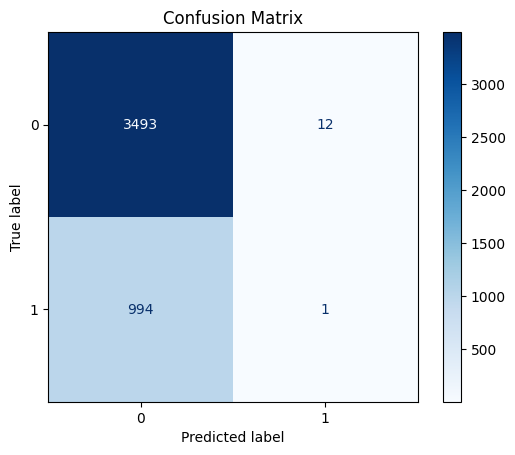

In [43]:
# Evaluate the model
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [44]:
#task3:hyperparameter tuning

In [45]:
#defining search space
learning_rates = [0.001, 0.01, 0.1]

architectures = [
    [X_train.shape[1], 8, 1],
    [X_train.shape[1], 16, 8, 1]
]

optimizers = ["sgd", "adam"]

In [46]:
#running all combinations
results = []

for lr in learning_rates:
    for arch in architectures:
        for opt in optimizers:

            print(f"\nTraining → LR={lr}, Arch={arch}, Opt={opt}")

            weights, biases, train_losses, val_losses = train(
                X_train, y_train,
                X_val, y_val,
                layers=arch,
                lr=lr,
                epochs=50,
                optimizer=opt,
                dropout_rate=0.2,
                patience=5
            )

            # Validation predictions
            y_val_pred = predict(X_val, weights, biases)

            acc = accuracy_score(y_val, y_val_pred)
            prec = precision_score(y_val, y_val_pred)
            rec = recall_score(y_val, y_val_pred)
            f1 = f1_score(y_val, y_val_pred)

            results.append({
                "Learning Rate": lr,
                "Architecture": str(arch),
                "Optimizer": opt,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1 Score": f1,
                "Final Val Loss": val_losses[-1]
            })


Training → LR=0.001, Arch=[26, 8, 1], Opt=sgd
Epoch 0 | Train Loss: 11.6191 | Val Loss: 3.9502
Epoch 1 | Train Loss: 3.7443 | Val Loss: 0.7009
Epoch 2 | Train Loss: 0.7106 | Val Loss: 0.6969
Epoch 3 | Train Loss: 0.6980 | Val Loss: 0.6968
Epoch 4 | Train Loss: 0.6937 | Val Loss: 0.6967
Epoch 5 | Train Loss: 0.6945 | Val Loss: 0.6966
Epoch 6 | Train Loss: 0.6944 | Val Loss: 0.6966
Epoch 7 | Train Loss: 0.6943 | Val Loss: 0.6965
Epoch 8 | Train Loss: 0.6934 | Val Loss: 0.6964
Epoch 9 | Train Loss: 0.6942 | Val Loss: 0.6963


C:\Users\91759\AppData\Local\Temp\ipykernel_33620\627952258.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-Z))


Epoch 10 | Train Loss: 0.6941 | Val Loss: 0.6962
Epoch 11 | Train Loss: 0.6940 | Val Loss: 0.6962
Epoch 12 | Train Loss: 0.6939 | Val Loss: 0.6961
Epoch 13 | Train Loss: 0.6939 | Val Loss: 0.6960
Epoch 14 | Train Loss: 0.6929 | Val Loss: 0.6959
Epoch 15 | Train Loss: 0.6937 | Val Loss: 0.6959
Epoch 16 | Train Loss: 0.6936 | Val Loss: 0.6958
Epoch 17 | Train Loss: 0.6932 | Val Loss: 0.6957
Epoch 18 | Train Loss: 0.6928 | Val Loss: 0.6956
Epoch 19 | Train Loss: 0.6925 | Val Loss: 0.6955
Epoch 20 | Train Loss: 0.6916 | Val Loss: 0.6955
Epoch 21 | Train Loss: 0.6915 | Val Loss: 0.6954
Epoch 22 | Train Loss: 0.6923 | Val Loss: 0.6953
Epoch 23 | Train Loss: 0.6922 | Val Loss: 0.6952
Epoch 24 | Train Loss: 0.6922 | Val Loss: 0.6951
Epoch 25 | Train Loss: 0.6921 | Val Loss: 0.6951
Epoch 26 | Train Loss: 0.6920 | Val Loss: 0.6950
Epoch 27 | Train Loss: 0.6911 | Val Loss: 0.6949
Epoch 28 | Train Loss: 0.6919 | Val Loss: 0.6948
Epoch 29 | Train Loss: 0.6918 | Val Loss: 0.6948
Epoch 30 | Train Los

C:\Users\91759\AppData\Local\Temp\ipykernel_33620\627952258.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-Z))
C:\Users\91759\AppData\Local\Temp\ipykernel_33620\627952258.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-Z))


Epoch 6 | Train Loss: 5.3077 | Val Loss: 4.1426
Early stopping triggered

Training → LR=0.001, Arch=[26, 16, 8, 1], Opt=sgd
Epoch 0 | Train Loss: 5.2720 | Val Loss: 8.2975
Epoch 1 | Train Loss: 8.3067 | Val Loss: 3.9502
Epoch 2 | Train Loss: 4.9753 | Val Loss: 0.6969
Epoch 3 | Train Loss: 0.6972 | Val Loss: 0.6928
Epoch 4 | Train Loss: 0.6937 | Val Loss: 0.6928
Epoch 5 | Train Loss: 0.6936 | Val Loss: 0.6927
Epoch 6 | Train Loss: 0.6936 | Val Loss: 0.6926
Epoch 7 | Train Loss: 0.6927 | Val Loss: 0.6925
Epoch 8 | Train Loss: 0.6926 | Val Loss: 0.6925
Epoch 9 | Train Loss: 0.6934 | Val Loss: 0.6924
Epoch 10 | Train Loss: 0.6924 | Val Loss: 0.6923
Epoch 11 | Train Loss: 0.6924 | Val Loss: 0.6922
Epoch 12 | Train Loss: 0.6923 | Val Loss: 0.6921
Epoch 13 | Train Loss: 0.6931 | Val Loss: 0.6921
Epoch 14 | Train Loss: 0.6922 | Val Loss: 0.6920
Epoch 15 | Train Loss: 0.6921 | Val Loss: 0.6919
Epoch 16 | Train Loss: 0.6920 | Val Loss: 0.6918
Epoch 17 | Train Loss: 0.6919 | Val Loss: 0.6917
Epoc

...

C:\Users\91759\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\91759\AppData\Local\Temp\ipykernel_33620\627952258.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-Z))
C:\Users\91759\AppData\Local\Temp\ipykernel_33620\627952258.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-Z))



Training → LR=0.1, Arch=[26, 16, 8, 1], Opt=sgd
Epoch 0 | Train Loss: 12.3979 | Val Loss: 3.9502
Epoch 1 | Train Loss: 4.0744 | Val Loss: 0.6844
Epoch 2 | Train Loss: 0.6847 | Val Loss: 0.6745
Epoch 3 | Train Loss: 0.6751 | Val Loss: 0.6676
Epoch 4 | Train Loss: 0.6684 | Val Loss: 0.6610
Epoch 5 | Train Loss: 0.6620 | Val Loss: 0.6548
Epoch 6 | Train Loss: 0.6560 | Val Loss: 0.6488
Epoch 7 | Train Loss: 0.6502 | Val Loss: 0.6431
Epoch 8 | Train Loss: 0.6447 | Val Loss: 0.6377
Epoch 9 | Train Loss: 0.6395 | Val Loss: 0.6326
Epoch 10 | Train Loss: 0.6345 | Val Loss: 0.6277
Epoch 11 | Train Loss: 0.6298 | Val Loss: 0.6230
Epoch 12 | Train Loss: 0.6253 | Val Loss: 0.6186
Epoch 13 | Train Loss: 0.6211 | Val Loss: 0.6144
Epoch 14 | Train Loss: 0.6170 | Val Loss: 0.6103
Epoch 15 | Train Loss: 0.6131 | Val Loss: 0.6065
Epoch 16 | Train Loss: 0.6095 | Val Loss: 0.6029
Epoch 17 | Train Loss: 0.6060 | Val Loss: 0.5994
Epoch 18 | Train Loss: 0.6026 | Val Loss: 0.5960
Epoch 19 | Train Loss: 0.5994

C:\Users\91759\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\91759\AppData\Local\Temp\ipykernel_33620\627952258.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-Z))



Training → LR=0.1, Arch=[26, 16, 8, 1], Opt=adam
Epoch 0 | Train Loss: 13.2605 | Val Loss: 3.9502
Epoch 1 | Train Loss: 4.0758 | Val Loss: 3.9511
Epoch 2 | Train Loss: 3.6322 | Val Loss: 2.5970
Epoch 3 | Train Loss: 2.5581 | Val Loss: 0.5632
Epoch 4 | Train Loss: 1.0586 | Val Loss: 0.5532
Epoch 5 | Train Loss: 0.7006 | Val Loss: 0.5412
Epoch 6 | Train Loss: 0.6510 | Val Loss: 0.5306
Epoch 7 | Train Loss: 0.5994 | Val Loss: 0.5234
Epoch 8 | Train Loss: 0.5789 | Val Loss: 0.5201
Epoch 9 | Train Loss: 0.5503 | Val Loss: 0.5201
Epoch 10 | Train Loss: 0.5578 | Val Loss: 0.5222
Epoch 11 | Train Loss: 0.5480 | Val Loss: 0.5248
Epoch 12 | Train Loss: 0.5760 | Val Loss: 0.5271
Epoch 13 | Train Loss: 0.5834 | Val Loss: 0.5282
Early stopping triggered


C:\Users\91759\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [47]:
#creating comparison table
results_df = pd.DataFrame(results)

# Sort by best F1 (better than accuracy for imbalance)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df

,Learning Rate,Architecture,Optimizer,Accuracy,Precision,Recall,F1 Score,Final Val Loss
7,0.010,"[26, 16, 8, 1]",adam,0.782889,0.300000,0.009326,0.018090,6.499123
1,0.001,"[26, 8, 1]",adam,0.777111,0.120000,0.006218,0.011823,4.142606
3,0.001,"[26, 16, 8, 1]",adam,0.779111,0.128205,0.005181,0.009960,4.068924
5,0.010,"[26, 8, 1]",adam,0.785333,0.333333,0.001036,0.002066,1.646517
0,0.001,"[26, 8, 1]",sgd,0.785333,0.000000,0.000000,0.000000,0.693203
2,0.001,"[26, 16, 8, 1]",sgd,0.785556,0.000000,0.000000,0.000000,0.689252
4,0.010,"[26, 8, 1]",sgd,0.785556,0.000000,0.000000,0.000000,0.658842
6,0.010,"[26, 16, 8, 1]",sgd,0.785556,0.000000,0.000000,0.000000,0.657937
8,0.100,"[26, 8, 1]",sgd,0.785556,0.000000,0.000000,0.000000,0.542330
9,0.100,"[26, 8, 1]",adam,0.785333,0.000000,0.000000,0.000000,5.835758


In [48]:
#highlighting best model
best = results_df.iloc[0]

print("Best Configuration:\n")
print(best)

Best Configuration:

Learning Rate               0.01
Architecture      [26, 16, 8, 1]
Optimizer                   adam
Accuracy                0.782889
Precision                    0.3
Recall                  0.009326
F1 Score                 0.01809
Final Val Loss          6.499123
Name: 7, dtype: object


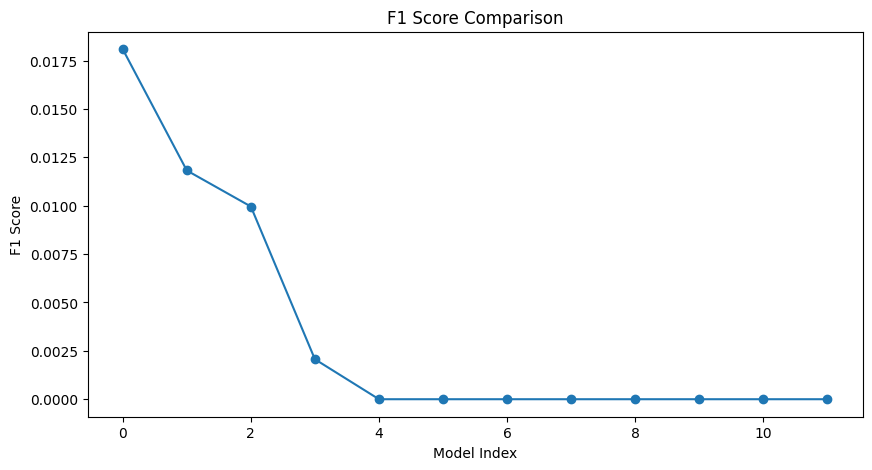

In [49]:
#optimal (visual comparison)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(results_df["F1 Score"].values, marker='o')
plt.title("F1 Score Comparison")
plt.xlabel("Model Index")
plt.ylabel("F1 Score")
plt.show()

In [50]:
#task 4: model evaluation

In [51]:
y_pred = predict(X_test, weights, biases)

In [52]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [53]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

C:\Users\91759\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [54]:
print(" Model Evaluation:\n")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix:\n", cm)

 Model Evaluation:

Accuracy : 0.7788888888888889
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Confusion Matrix:
 [[3505    0]
 [ 995    0]]


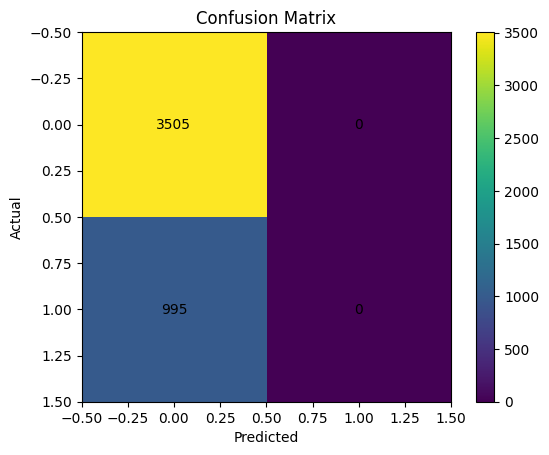

In [55]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [56]:
#task5: visualisation

# Extract parameters of the best model
best_lr = best["Learning Rate"]
best_arch = eval(best["Architecture"])
best_opt = best["Optimizer"]
best_name = f"LR={best_lr}, Arch={best_arch}, Opt={best_opt}"

print(f"Re-training best model: {best_name}")

# Re-train the best model to get its full training history
best_weights, best_biases, train_losses_best, val_losses_best = train(
    X_train, y_train,
    X_val, y_val,
    layers=best_arch,
    lr=best_lr,
    epochs=100, # Using more epochs to see full training curve
    optimizer=best_opt,
    dropout_rate=0.2, # Assuming dropout rate used in tuning was 0.2
    patience=10 # Assuming patience used in tuning was 10
)

best_history = {
    'train_loss': train_losses_best,
    'val_loss': val_losses_best
}

# Calculate predictions for the best model on the test set
y_pred_best = predict(X_test, best_weights, best_biases)

Re-training best model: LR=0.01, Arch=[26, 16, 8, 1], Opt=adam
Epoch 0 | Train Loss: 7.1305 | Val Loss: 4.1794


C:\Users\91759\AppData\Local\Temp\ipykernel_33620\627952258.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-Z))


Epoch 1 | Train Loss: 6.2573 | Val Loss: 4.1549
Epoch 2 | Train Loss: 5.9599 | Val Loss: 4.1427
Epoch 3 | Train Loss: 5.8222 | Val Loss: 4.1373
Epoch 4 | Train Loss: 5.9615 | Val Loss: 4.3321
Epoch 5 | Train Loss: 6.1151 | Val Loss: 4.4424
Epoch 6 | Train Loss: 5.9900 | Val Loss: 4.4127
Epoch 7 | Train Loss: 5.9479 | Val Loss: 4.0923
Epoch 8 | Train Loss: 5.8538 | Val Loss: 3.9520
Epoch 9 | Train Loss: 5.6973 | Val Loss: 3.9561
Epoch 10 | Train Loss: 5.5684 | Val Loss: 3.9666
Epoch 11 | Train Loss: 5.4699 | Val Loss: 3.9872
Epoch 12 | Train Loss: 5.3724 | Val Loss: 3.9853
Epoch 13 | Train Loss: 5.1726 | Val Loss: 3.9870
Epoch 14 | Train Loss: 5.1501 | Val Loss: 3.9993
Epoch 15 | Train Loss: 5.1630 | Val Loss: 4.0003
Epoch 16 | Train Loss: 5.1244 | Val Loss: 4.0009
Epoch 17 | Train Loss: 4.9692 | Val Loss: 3.9853
Epoch 18 | Train Loss: 4.7753 | Val Loss: 3.8792
Epoch 19 | Train Loss: 4.6504 | Val Loss: 3.5384
Epoch 20 | Train Loss: 4.4438 | Val Loss: 3.5252
Epoch 21 | Train Loss: 4.2341

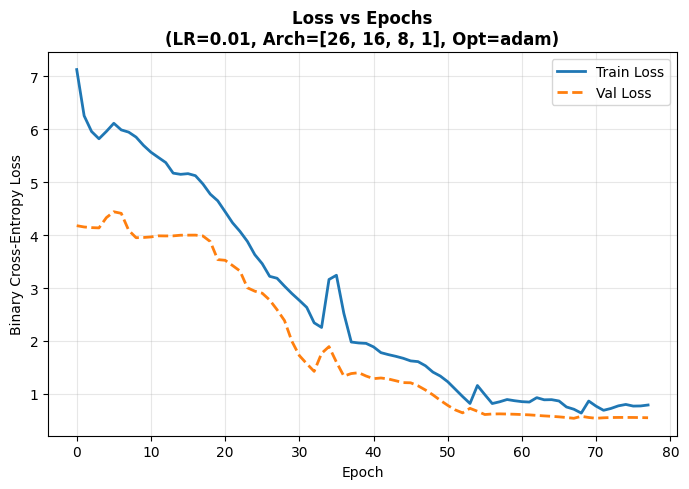

In [57]:
# ── Plot 1: Loss vs Epochs for best model ────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(7, 5)) # Changed to single subplot for loss only

ax.plot(best_history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(best_history['val_loss'],   label='Val Loss',   linewidth=2, linestyle='--')
ax.set_title(f'Loss vs Epochs\n({best_name})', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

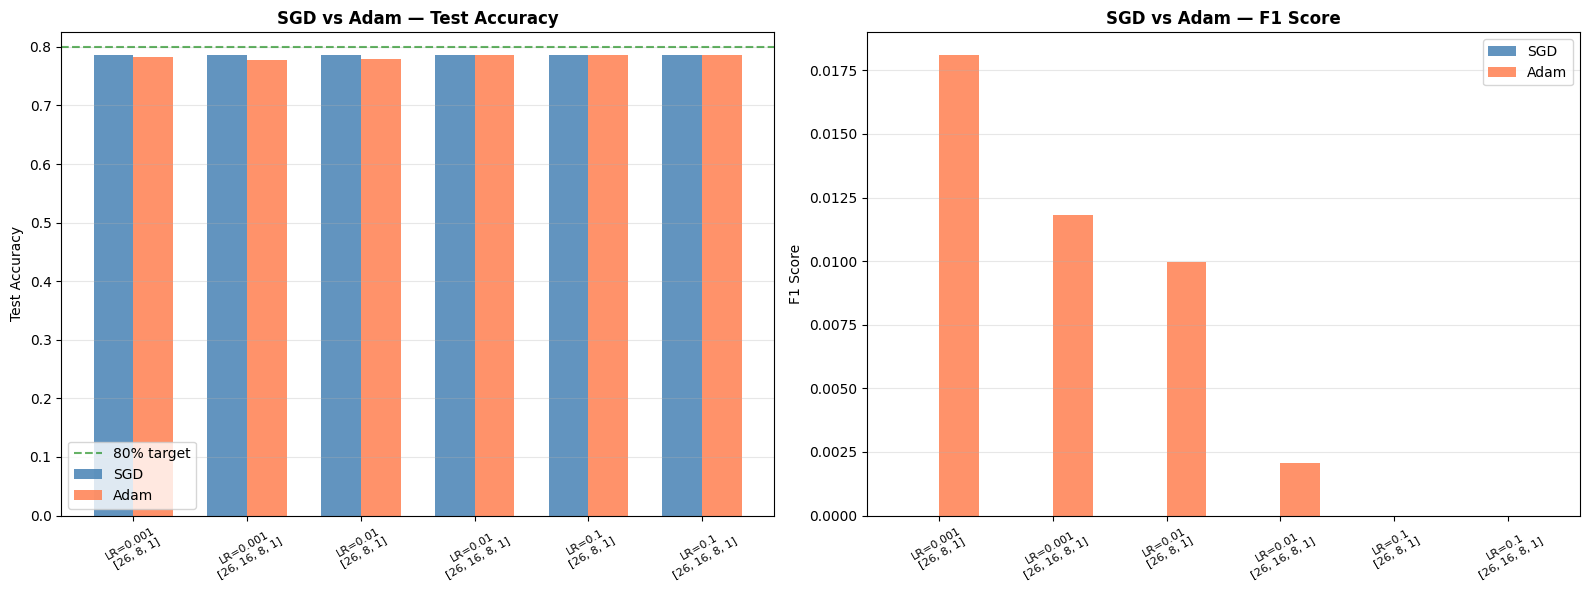

In [58]:
# ── Plot 2: SGD vs Adam comparison (final val loss for each config) ─────
sgd_results  = results_df[results_df['Optimizer'] == 'sgd']
adam_results = results_df[results_df['Optimizer'] == 'adam']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
x = np.arange(len(sgd_results))
width = 0.35
axes[0].bar(x - width/2, sgd_results['Accuracy'].values,  width, label='SGD',  color='steelblue', alpha=0.85)
axes[0].bar(x + width/2, adam_results['Accuracy'].values, width, label='Adam', color='coral',     alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'LR={r}\n{a}' for r, a in zip(sgd_results['Learning Rate'], sgd_results['Architecture'])],
                          rotation=30, fontsize=8)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('SGD vs Adam — Test Accuracy', fontweight='bold')
axes[0].axhline(0.8, color='green', linestyle='--', alpha=0.6, label='80% target')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# F1 comparison
axes[1].bar(x - width/2, sgd_results['F1 Score'].values,  width, label='SGD',  color='steelblue', alpha=0.85)
axes[1].bar(x + width/2, adam_results['F1 Score'].values, width, label='Adam', color='coral',     alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'LR={r}\n{a}' for r, a in zip(sgd_results['Learning Rate'], sgd_results['Architecture'])],
                          rotation=30, fontsize=8)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('SGD vs Adam — F1 Score', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

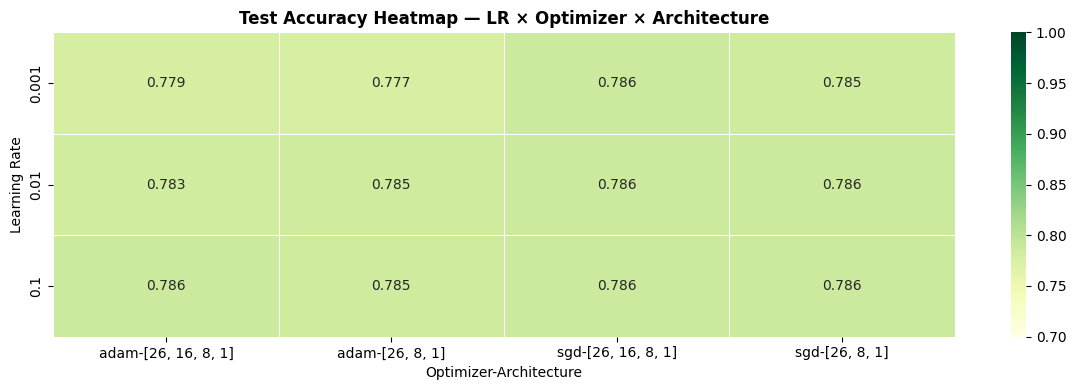

In [59]:
# ── Plot 3: Learning-rate effect heatmap ─────
pivot_acc = results_df.pivot_table(
    index='Learning Rate', columns=['Optimizer','Architecture'], values='Accuracy')

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot_acc, annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, ax=ax, vmin=0.7, vmax=1.0)
ax.set_title('Test Accuracy Heatmap — LR × Optimizer × Architecture',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [60]:
# ── Extended model: ReLU + Dropout (0.3) + Early Stopping ─────
print('Training extended ANN: ReLU + Dropout(0.3) + Early Stopping...')
print('='*60)

best_weights_ext, best_biases_ext, train_losses_ext, val_losses_ext = train(
    X_train, y_train, X_val, y_val,
    layers     = [X_train.shape[1], 16, 8, 1],
    lr             = 0.001,
    epochs         = 500,
    optimizer      = 'adam',
    # hidden_act     = 'relu', # This parameter is not part of the `train` function's signature
    dropout_rate   = 0.3,
    patience       = 20
    # verbose        = True # This parameter is not part of the `train` function's signature
)

ext_params = (best_weights_ext, best_biases_ext)
ext_history = {
    'train_loss': train_losses_ext,
    'val_loss': val_losses_ext
}

y_pred_ext = predict(X_test, ext_params[0], ext_params[1])
print('\nExtended Model Metrics:')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_ext):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_ext):.4f}')
print(f'  Recall   : {recall_score(y_test, y_pred_ext):.4f}')
print(f'  F1-Score : {f1_score(y_test, y_pred_ext):.4f}')

Training extended ANN: ReLU + Dropout(0.3) + Early Stopping...
Epoch 0 | Train Loss: 10.2369 | Val Loss: 13.2094
Epoch 1 | Train Loss: 10.1303 | Val Loss: 13.0386
Epoch 2 | Train Loss: 10.0265 | Val Loss: 12.9273
Epoch 3 | Train Loss: 10.0052 | Val Loss: 12.8397


C:\Users\91759\AppData\Local\Temp\ipykernel_33620\627952258.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-Z))


Epoch 4 | Train Loss: 10.0095 | Val Loss: 12.6607
Epoch 5 | Train Loss: 9.7614 | Val Loss: 12.4990
Epoch 6 | Train Loss: 9.7603 | Val Loss: 12.3089
Epoch 7 | Train Loss: 9.6181 | Val Loss: 12.1092
Epoch 8 | Train Loss: 9.5996 | Val Loss: 11.9284
Epoch 9 | Train Loss: 9.5500 | Val Loss: 11.7434
Epoch 10 | Train Loss: 9.3990 | Val Loss: 11.4992
Epoch 11 | Train Loss: 9.4551 | Val Loss: 11.2776
Epoch 12 | Train Loss: 9.3134 | Val Loss: 11.0439
Epoch 13 | Train Loss: 9.1571 | Val Loss: 10.7112
Epoch 14 | Train Loss: 9.2262 | Val Loss: 10.4461
Epoch 15 | Train Loss: 9.0743 | Val Loss: 10.2370
Epoch 16 | Train Loss: 8.9573 | Val Loss: 9.9758
Epoch 17 | Train Loss: 8.9858 | Val Loss: 9.8095
Epoch 18 | Train Loss: 8.8155 | Val Loss: 9.6618
Epoch 19 | Train Loss: 8.8820 | Val Loss: 9.5312
Epoch 20 | Train Loss: 8.7931 | Val Loss: 9.4324
Epoch 21 | Train Loss: 8.7032 | Val Loss: 9.3346
Epoch 22 | Train Loss: 8.6749 | Val Loss: 9.2382
Epoch 23 | Train Loss: 8.4504 | Val Loss: 9.1748
Epoch 24 | Tr

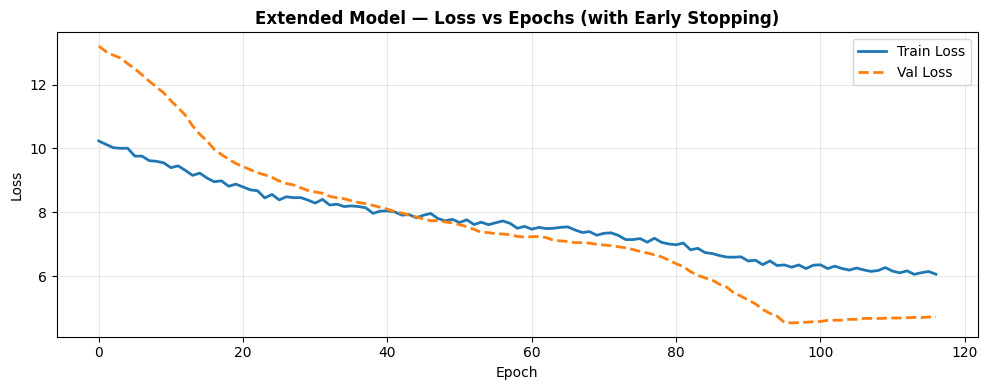

In [61]:
# ── Loss curve for extended model ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ext_history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(ext_history['val_loss'],   label='Val Loss',   linewidth=2, linestyle='--')
ax.set_title('Extended Model — Loss vs Epochs (with Early Stopping)', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
#final comparison ; ANN vs Logistic Regression vs Decision Tree

In [63]:
# ── Sklearn baseline models (allowed for evaluation/comparison) ──────────
# Use the already-normalised X for LR & DT

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train.ravel())
y_pred_lr = lr_model.predict(X_test)

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train.ravel())
y_pred_dt = dt_model.predict(X_test)

# ── Results table ─────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model': ['ANN (Best Tuned)', 'ANN (Extended: ReLU+Dropout+ES)',
              'Logistic Regression', 'Decision Tree'],
    'Accuracy' : [
        accuracy_score(y_test, y_pred_best),
        accuracy_score(y_test, y_pred_ext),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    'Precision': [
        precision_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_ext),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt)
    ],
    'Recall': [
        recall_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_ext),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_ext),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt)
    ]
}).round(4)

print('='*70)
print('FINAL MODEL COMPARISON')
print('='*70)
print(comparison.to_string(index=False))
print('='*70)

C:\Users\91759\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


FINAL MODEL COMPARISON
                          Model  Accuracy  Precision  Recall  F1-Score
               ANN (Best Tuned)    0.7789     0.0000  0.0000    0.0000
ANN (Extended: ReLU+Dropout+ES)    0.7438     0.1624  0.0382    0.0618
            Logistic Regression    0.8071     0.6693  0.2523    0.3664
                  Decision Tree    0.8202     0.6673  0.3729    0.4784


C:\Users\91759\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


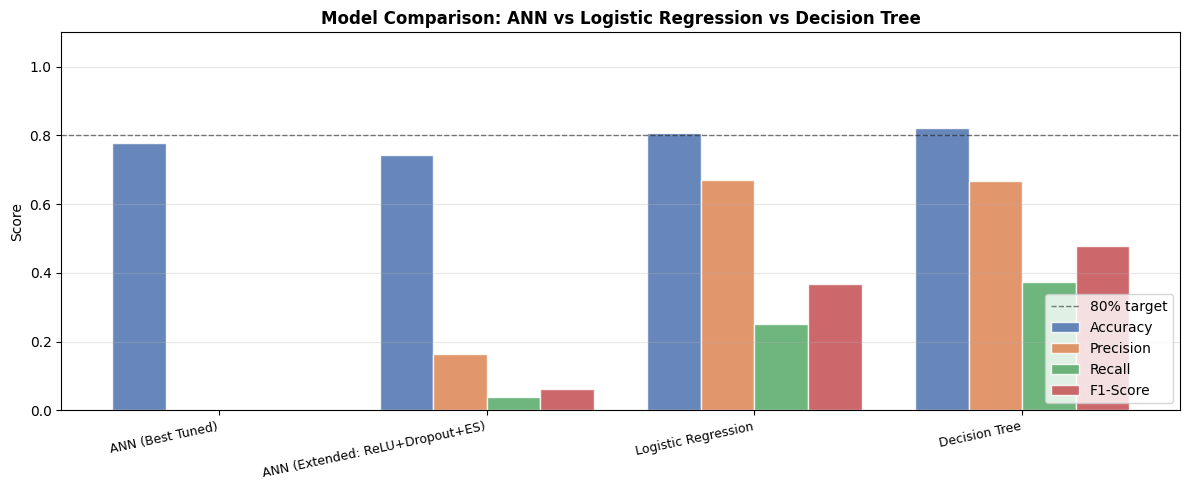

In [64]:
# ── Final comparison bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x      = np.arange(len(comparison))
width  = 0.2
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for i, (metric, color) in enumerate(zip(metrics_list, colors)):
    bars = ax.bar(x + (i - 1.5) * width, comparison[metric],
                  width, label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], rotation=12, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: ANN vs Logistic Regression vs Decision Tree',
             fontweight='bold', fontsize=12)
ax.axhline(0.8, color='black', linestyle='--', alpha=0.5, linewidth=1, label='80% target')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

